In [ ]:
path_training = './Training'
path_testing = './Testing'
import os 
import cv2
import numpy as np
from sklearn.utils import shuffle

labels = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

x_train = []
y_train = []
# carregando as imagens
for i in labels:
    path = os.path.join(path_training, i)
    for j in os.listdir(path):
        img = cv2.imread(os.path.join(path,j))
        img = cv2.resize(img, (128,128))
        img = img/255
        x_train.append(img)
        y_train.append(i)
        
# Teste
for i in labels:
    path = os.path.join(path_testing, i)
    for j in os.listdir(path):
        img = cv2.imread(os.path.join(path,j))
        img = cv2.resize(img, (128,128))
        img = img/255
        x_train.append(img)
        y_train.append(i)

# convertendo as imagens para arrayx_train = np.array(x_train)
y_train = np.array(y_train)

x_train, y_train = shuffle(x_train, y_train, random_state=101)

from sklearn.model_selection import train_test_split

# separando imagens de treino e teste / rotulos de treino e teste
x_train, x_test, y_train, y_test = train_test_split(x_train, y_train, test_size=0.3, random_state=101)


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Dense, Dropout, Flatten
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# Carregando os rótulos
y_new_train = []
for i in y_train:
    y_new_train.append(labels.index(i))

y_train = y_new_train
y_train = tf.keras.utils.to_categorical(y_train)

y_new_test = []
for i in y_test:
    y_new_test.append(labels.index(i))

y_test = y_new_test
y_test = tf.keras.utils.to_categorical(y_test)

# criando rede neural cnn
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same',input_shape=(128,128,3), kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.3),
    
    Conv2D(128, (3,3), activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu',kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(128, (3,3), activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.3),
    Conv2D(256, (3,3), activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Flatten(),
    
    Dropout(0.3),
    Dense(512, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    
    Dense(4, activation='softmax')  
])

cnn_model.summary()


# criando callbacks para evitar overfittingearly_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lrn = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5)
cnn_model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

# treinando modelo
history = cnn_model.fit(x_train, y_train, epochs=25, validation_data=(x_test, y_test), verbose=1, callbacks=[early_stop, reduce_lrn])

cnn_model.save("cnn_tumor_02.h5")

 # analise de acuracia e perda
loss, accuracy = cnn_model.evaluate(x_test, y_test)

print(f'Acurácia: {accuracy}')
print(f'Perda: {loss}')


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_201 (Conv2D)             │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_202 (Conv2D)             │ (None, 126, 126, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_96 (MaxPooling2D) │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_80 (Dropout)            │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_203 (Conv2D)             │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_204 (Conv2D)             │ (None, 59, 59, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_81 (Dropout)            │ (None, 59, 59, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_97 (MaxPooling2D) │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_82 (Dropout)            │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_205 (Conv2D)             │ (None, 27, 27, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_206 (Conv2D)             │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_207 (Conv2D)             │ (None, 23, 23, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_98 (MaxPooling2D) │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_83 (Dropout)            │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_208 (Conv2D)             │ (None, 9, 9, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_209 (Conv2D)             │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_99 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_84 (Dropout)            │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_22 (Flatten)            │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_85 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,349,892 (8.96 MB)

 Trainable params: 2,349,892 (8.96 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.2850 - loss: 1.3800 - val_accuracy: 0.2612 - val_loss: 1.4420 - learning_rate: 0.0010
Epoch 2/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.2784 - loss: 1.3422 - val_accuracy: 0.3061 - val_loss: 1.3619 - learning_rate: 0.0010
Epoch 3/25
53/72 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.3914 - loss: 1.2678

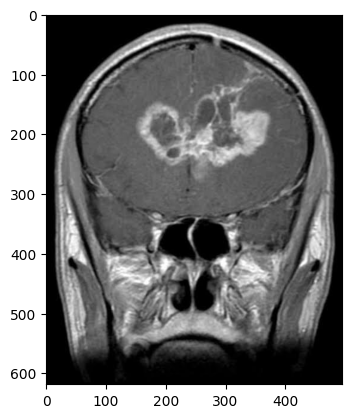

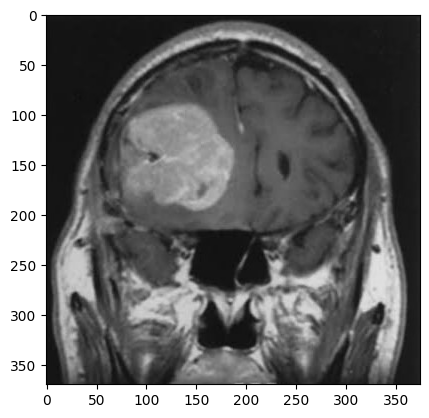

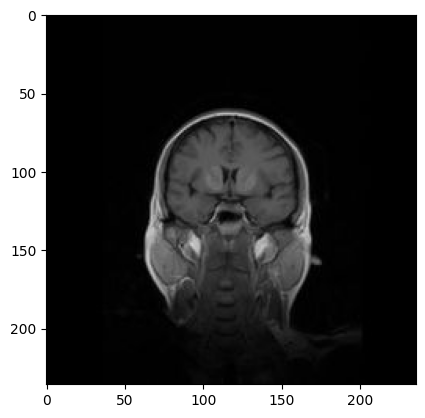

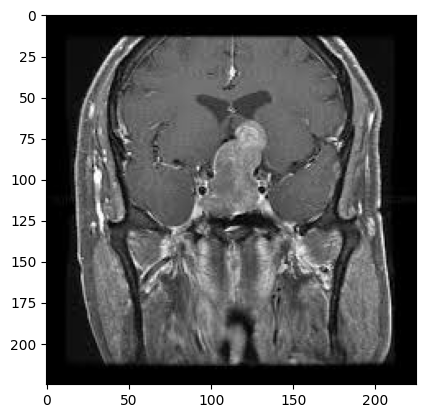

In [32]:
from tensorflow.keras.preprocessing.image import load_img
import matplotlib.pyplot as plt

glioma_path = './Testing/glioma_tumor/image.jpg'
meningioma_path = './Testing/meningioma_tumor/image(15).jpg'
no_tumor_path = './Testing/no_tumor/image(68).jpg'
pituitary_path = './Testing/pituitary_tumor/image(49).jpg'

glioma_img = load_img(glioma_path)

plt.imshow(glioma_img)
plt.show()

meningioma_img = load_img(meningioma_path)
plt.imshow(meningioma_img)
plt.show()

no_tumor_img = load_img(no_tumor_path)

plt.imshow(no_tumor_img)
plt.show()

pituitary_img = load_img(pituitary_path)

plt.imshow(pituitary_img)
plt.show()


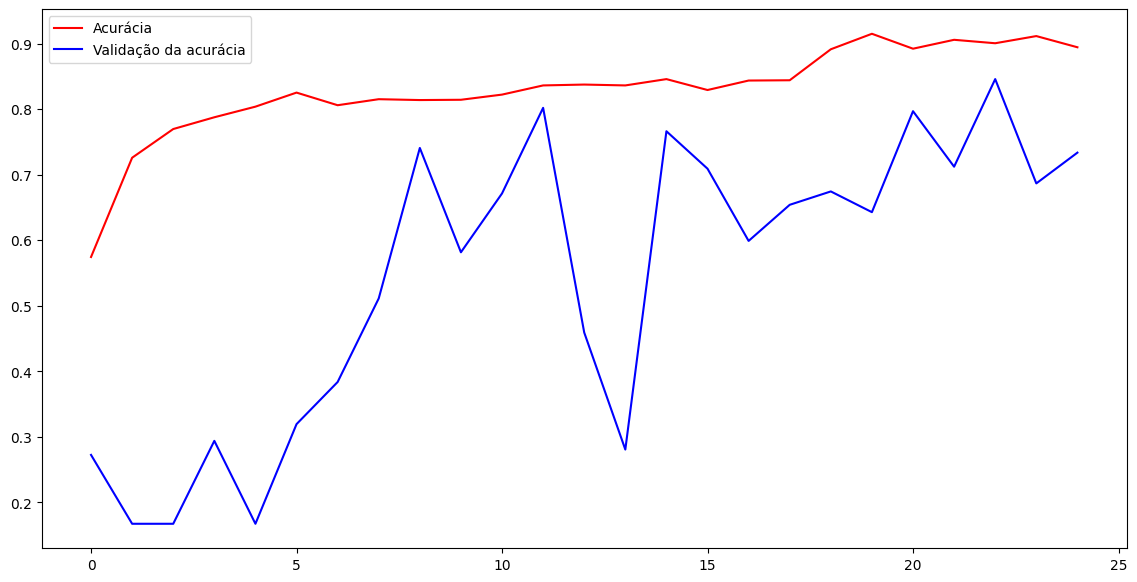

In [33]:

acc = history.history['accuracy']

val_accuracy = history.history['val_accuracy']

epochs = range(len(acc))

fig = plt.figure(figsize=(14,7))

plt.plot(epochs, acc, 'r', label="Acurácia")
plt.plot(epochs, val_accuracy, 'b', label='Validação da acurácia')
plt.legend(loc='upper left')
plt.show()

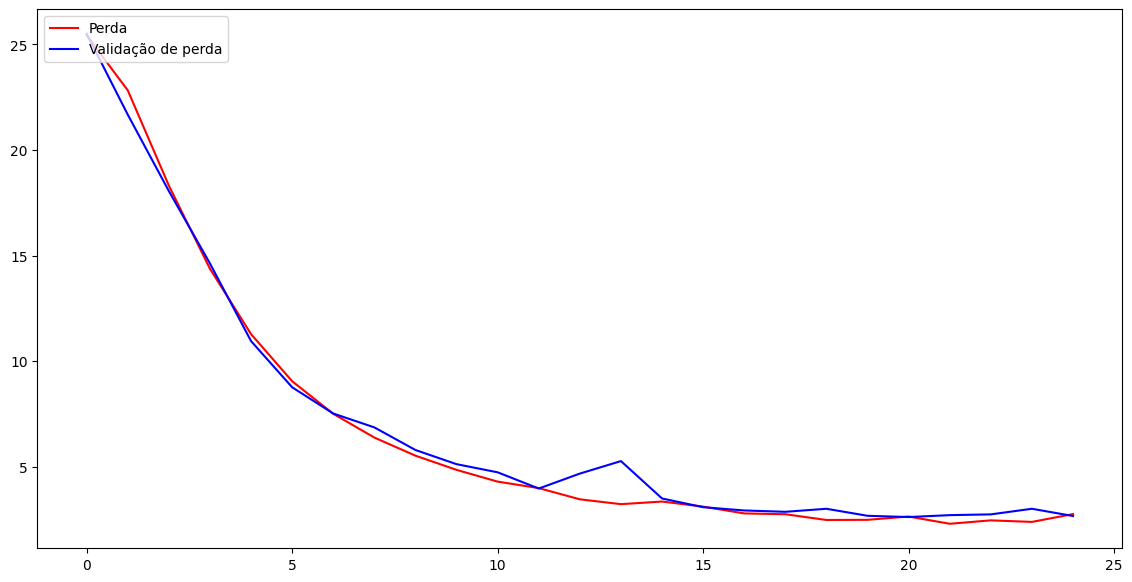

In [10]:
loss = history.history['loss']

val_loss = history.history['val_loss']

epochs = range(len(loss))

plt.figure(figsize=(14,7))

plt.plot(epochs, loss, 'r', label='Perda')
plt.plot(epochs, val_loss, 'b', label='Validação de perda')
plt.legend(loc='upper left')
plt.show()